In [1]:
import os
os.chdir(r"C:\Users\PC\Downloads\AI\Computer Vision Quality Inspector")

In [2]:
os.getcwd()

'C:\\Users\\PC\\Downloads\\AI\\Computer Vision Quality Inspector'

In [3]:
import torch
print(torch.__version__)


2.5.1+cu121


In [4]:
import torch
print(torch.cuda.is_available())        # should be True
print(torch.cuda.device_count())        # should be >0
print(torch.cuda.get_device_name(0))    # should print "NVIDIA GeForce RTX 3070"


True
1
NVIDIA GeForce RTX 3070 Laptop GPU


In [5]:
from pathlib import Path

print(Path("NEU_data/NEU-DET/train/images").exists())
print(Path("NEU_data/NEU-DET/validation/images").exists())


True
True


In [6]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path


In [5]:
import sys
print(sys.executable)


c:\Users\PC\miniconda3\envs\tf220\python.exe


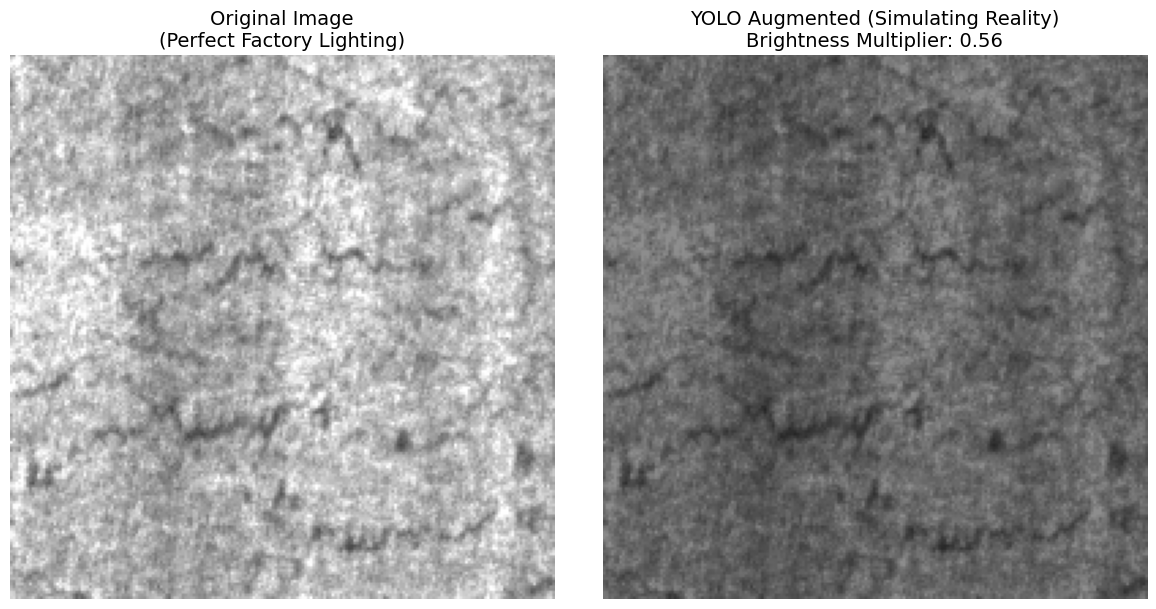

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

def apply_yolo_augmentations(image_path, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, bgr_prob=0.1):
    # 1. Load the original image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found! Check the file path.")

    # Convert to Float32 for accurate math
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)

    # 2. Generate random gains based on your hyperparameters
    # YOLO multiplies the channels by a random float between (1 - variance) and (1 + variance)
    gain_h = np.random.uniform(-1, 1) * hsv_h + 1
    gain_s = np.random.uniform(-1, 1) * hsv_s + 1
    gain_v = np.random.uniform(-1, 1) * hsv_v + 1  # 0.4 to 1.6 (creates shadows or bright glares!)

    # 3. Apply the gains
    hsv[:, :, 0] = (hsv[:, :, 0] * gain_h) % 180       # OpenCV Hue range is 0-179
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * gain_s, 0, 255) # Saturation 0-255
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * gain_v, 0, 255) # Value/Brightness 0-255

    # Convert back to standard 8-bit BGR image
    aug_img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    # 4. Color Channels Swap (bgr=0.1)
    # There is a 10% chance the channels will swap (e.g., Red becomes Blue)
    channel_swapped = False
    if random.random() < bgr_prob:
        aug_img = aug_img[:, :, ::-1] # Swaps BGR to RGB
        channel_swapped = True

    return img, aug_img, gain_v, channel_swapped


# ==========================================
# Run the function and plot the results
# ==========================================
# Replace this with the path to one of your NEU-DET images
IMAGE_PATH = "NEU_data/NEU-DET/validation/images/crazing_241.jpg" 

original, augmented, brightness_gain, swapped = apply_yolo_augmentations(
    IMAGE_PATH, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, bgr_prob=0.1
)

# Convert BGR to RGB so Matplotlib displays colors correctly
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
augmented_rgb = cv2.cvtColor(augmented, cv2.COLOR_BGR2RGB)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image\n(Perfect Factory Lighting)", fontsize=14)
plt.imshow(original_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
title = f"YOLO Augmented (Simulating Reality)\nBrightness Multiplier: {brightness_gain:.2f}"
if swapped:
    title += " | Channels Swapped!"
plt.title(title, fontsize=14)
plt.imshow(augmented_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()

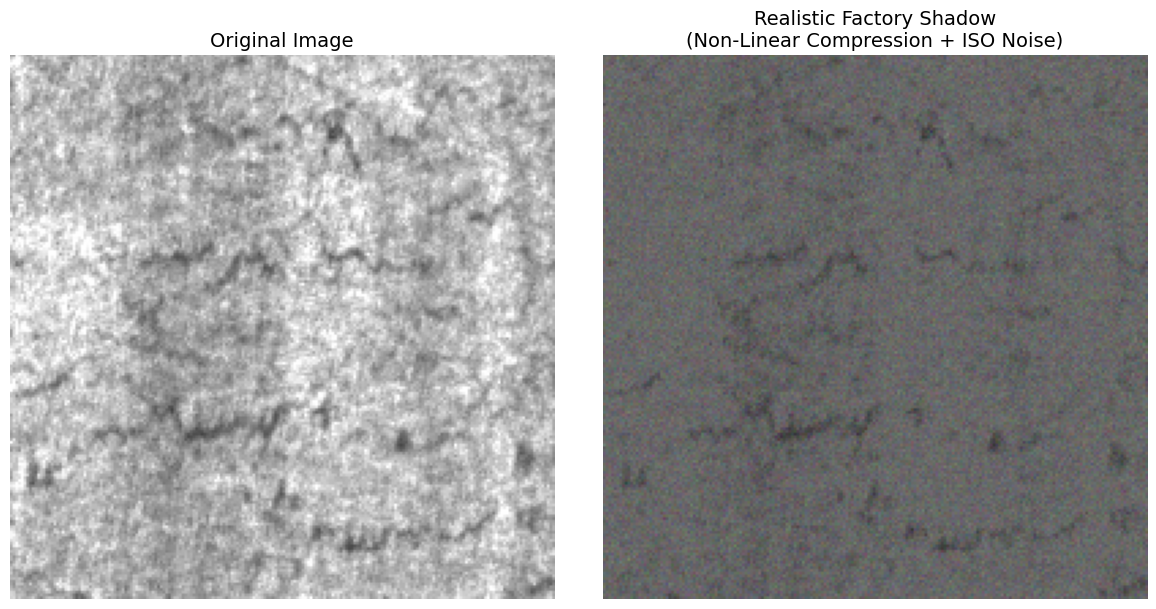

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_realistic_factory_shadow(image_path, shadow_intensity=0.65, add_noise=True):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found! Check the file path.")

    # convert to HSV and use float32 for precise math
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    V = hsv[:, :, 2] # extract the Value (Brightness) channel
    
    #applying non linear shadow curve
    # darks stay dark. lights get significantly darker. contrast is crushed.
    V_new = V - (V * (V / 255.0) * shadow_intensity)
    
    # apply back to the channel and clip to valid ranges
    hsv[:, :, 2] = np.clip(V_new, 0, 255)
    aug_img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    
    # we add camera iso noise
    # when factories are dark, camera sensors struggle and generate grain.
    if add_noise:
        # generate random Gaussian noise (mean=0, std=12)
        noise = np.random.normal(0, 8, aug_img.shape).astype(np.float32)
        aug_img = cv2.add(aug_img.astype(np.float32), noise)
        aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)

    return img, aug_img


IMAGE_PATH = "NEU_data/NEU-DET/validation/images/crazing_241.jpg" 

original, realistic_shadow = apply_realistic_factory_shadow(
    IMAGE_PATH, 
    shadow_intensity=0.6, # 0.0 is no shadow, 1.0 is maximum shadow
    add_noise=True
)

# convert BGR to RGB for accurate matplotlib colors
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
realistic_shadow_rgb = cv2.cvtColor(realistic_shadow, cv2.COLOR_BGR2RGB)

# plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image", fontsize=14)
plt.imshow(original_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Realistic Factory Shadow\n(Non-Linear Compression + ISO Noise)", fontsize=14)
plt.imshow(realistic_shadow_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
from tqdm import tqdm

# Paths based on your project structure
train_imgs_dir = Path('NEU_data/NEU-DET/dark_train/dark_images')
train_labels_dir= Path('NEU_data/NEU-DET/dark_train/dark_labels')
train_imgs_dir.mkdir(parents=True,exist_ok=True)
train_labels_dir.mkdir(parents=True,exist_ok=True)
train_imgs_path='NEU_data/NEU-DET/train/images'
train_labels_path='NEU_data/NEU-DET/train/labels'
def apply_realistic_factory_shadow(image, shadow_intensity=0.65, add_noise=True):
    # convert to HSV and use Float32 for precise math
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)
    V = hsv[:, :, 2]
    
    # non-linear shadow curve
    V_new = V - (V * (V / 255.0) * shadow_intensity)
    hsv[:, :, 2] = np.clip(V_new, 0, 255)
    
    aug_img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    
    if add_noise:
        noise = np.random.normal(0, 12, aug_img.shape).astype(np.float32)
        aug_img = cv2.add(aug_img.astype(np.float32), noise)
        aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)

    return aug_img

def generate_synthetic_dataset():
     
    images = [f for f in os.listdir(train_imgs_path) if f.endswith('.jpg') and '_dark' not in f]
    for img_name in tqdm(images):
        img_path = os.path.join(train_imgs_path, img_name)
        lbl_name = img_name.replace('.jpg', '.txt')
        lbl_path = os.path.join(train_labels_path, lbl_name)
        
        if not os.path.exists(lbl_path):
            continue
            
        img = cv2.imread(img_path)
        # randomize the shadow intensity slightly between 0.5 and 0.8 for variety
        intensity = np.random.uniform(0.5, 0.8)
        dark_img = apply_realistic_factory_shadow(img, shadow_intensity=intensity)
        
        # save the augmented image
        new_img_name = img_name.replace('.jpg', '_dark.jpg')
        new_img_path = os.path.join(train_imgs_dir, new_img_name)
        cv2.imwrite(new_img_path, dark_img)
        
        # 3. Duplicate the Label File (Since geometry didn't change!)
        new_lbl_name = lbl_name.replace('.txt', '_dark.txt')
        new_lbl_path = os.path.join(train_labels_dir, new_lbl_name)
        shutil.copy(lbl_path, new_lbl_path)

generate_synthetic_dataset()

100%|██████████| 1440/1440 [00:20<00:00, 70.71it/s]


In [ ]:
model=YOLO("yolov8n.pt")
history = model.train(
    data="NEU_data/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="neu_det_yolov8n",
    fliplr=0.5, 
    flipud=0.5,
    device=0
)

Ultralytics 8.4.51  Python-3.11.15 torch-2.5.1+cu121 CUDA:1 (NVIDIA GeForce RTX 3070 Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=NEU_data/data.yaml, degrees=0.0, deterministic=True, device=1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=neu_det_yolov8n-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

KeyboardInterrupt: 

In [ ]:
#View Training Results
from IPython.display import Image
Image(filename="runs/detect/neu_det_yolov8n/results.png")
metrics = model.val()
print(metrics)

In [ ]:
#predicttions
results = model.predict(
    source="NEU_data/NEU-DET/validation/images",
    save=True,
    imgsz=640
)

pred_dir = Path("runs/detect/predict")
pred_imgs = list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png"))
N = 9 
plt.figure(figsize=(15,15))
for i, img_path in enumerate(pred_imgs[:N]):
    img=cv2.imread(str(img_path))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(img_path.name,fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()



In [ ]:
#Export Model for Deployment
model.export(format="onnx")
model.export(format="engine")   # TensorRT
model.export(format="torchscript")


In [ ]:
#Confusion Matrix & PR Curve
Image(filename="runs/detect/neu_det_yolov8n/confusion_matrix.png")
Image(filename="runs/detect/neu_det_yolov8n/PR_curve.png")
